# L=32 raw-spin PCA — matched all-bin analysis

## Matched data and analysis design

Every saved configuration is one observation. All ten bins for all 10,000 seeds and all 41 temperatures are included independently: **4.1 million observations per representation**. PCA and K-means are fitted on the same balanced 410,000 observation subset, then evaluated on every configuration. No spin inversion, temperature label, supervised classifier, or configuration averaging is used.

In [1]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import adjusted_mutual_info_score, silhouette_score

L = 32
N_SITES = L ** 2
N_RUNS = 10_000
N_TEMPERATURES = 41
BINS_PER_TEMPERATURE = 10
N_CONFIGURATIONS = N_RUNS * N_TEMPERATURES * BINS_PER_TEMPERATURE
TEMPERATURES = np.round(np.linspace(2.200, 2.400, N_TEMPERATURES), 3)
TC = 2.0 / np.log(1.0 + np.sqrt(2.0))

candidate_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parents[1]]
REPO_ROOT = next(root for root in candidate_roots if (root / "data" / "raw" / "ising32_tc_zoom").exists())
DATA_ROOT = REPO_ROOT / "data" / "raw" / "ising32_tc_zoom"
OUTPUT_ROOT = REPO_ROOT / "data" / "processed" / "ising32_tc_zoom" / "matched_all_bins"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

run_dirs = sorted(DATA_ROOT.glob("ising32_tc_zoom_[0-9]*"), key=lambda p: int(p.name.rsplit("_", 1)[1]))
assert len(run_dirs) == N_RUNS

SPINS_PATH = OUTPUT_ROOT / "all_spin_configurations.npy"
if not SPINS_PATH.exists():
    cache = np.lib.format.open_memmap(
        SPINS_PATH, mode="w+", dtype=np.int8,
        shape=(N_CONFIGURATIONS, L, L),
    )
    offset = 0
    for run_index, run_dir in enumerate(run_dirs):
        name = run_dir.name
        block = np.loadtxt(run_dir / f"spinConfigs_{name}.txt", dtype=np.int8).reshape(-1, L, L)
        assert block.shape == (N_TEMPERATURES * BINS_PER_TEMPERATURE, L, L)
        cache[offset:offset + len(block)] = block
        offset += len(block)
        if (run_index + 1) % 500 == 0:
            print(f"Cached {run_index + 1:,}/{N_RUNS:,} runs")
    cache.flush()
    del cache

all_spins = np.load(SPINS_PATH, mmap_mode="r")
assert all_spins.shape == (N_CONFIGURATIONS, L, L)
configuration_temperatures = np.tile(np.repeat(TEMPERATURES, BINS_PER_TEMPERATURE), N_RUNS)

# The same balanced 410,000 configurations fit both PCA bases and both K-means models:
# one rotating bin for every seed-temperature pair. All 4.1 million configurations are
# subsequently transformed, assigned, and included in temperature-population curves.
run_ids = np.arange(N_RUNS)[:, None]
temperature_ids = np.arange(N_TEMPERATURES)[None, :]
fit_bins = (run_ids + temperature_ids) % BINS_PER_TEMPERATURE
FIT_INDICES = ((run_ids * N_TEMPERATURES + temperature_ids) * BINS_PER_TEMPERATURE + fit_bins).reshape(-1)
assert len(FIT_INDICES) == N_RUNS * N_TEMPERATURES

signed_magnetization = all_spins.reshape(N_CONFIGURATIONS, -1).mean(axis=1, dtype=np.float64).astype(np.float32)
print(f"{N_CONFIGURATIONS:,} matched configurations; {len(FIT_INDICES):,} balanced fit observations")
print(f"Temperature range: {TEMPERATURES[0]:.3f}–{TEMPERATURES[-1]:.3f}; device={torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")

4,100,000 matched configurations; 410,000 balanced fit observations
Temperature range: 2.200–2.400; device=cuda


In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def fit_covariance_pca(features, cache_path, batch_size=4096):
    if cache_path.exists():
        saved = np.load(cache_path)
        return saved["mean"], saved["eigenvalues"], saved["components"]
    dimension = features.shape[1]
    total = torch.zeros(dimension, dtype=torch.float64, device=DEVICE)
    second = torch.zeros((dimension, dimension), dtype=torch.float64, device=DEVICE)
    for start in range(0, len(FIT_INDICES), batch_size):
        indices = FIT_INDICES[start:start + batch_size]
        batch = torch.tensor(np.asarray(features[indices], dtype=np.float32), device=DEVICE, dtype=torch.float64)
        total += batch.sum(0)
        second += batch.T @ batch
    mean_t = total / len(FIT_INDICES)
    covariance = (second - len(FIT_INDICES) * torch.outer(mean_t, mean_t)) / (len(FIT_INDICES) - 1)
    values, vectors = torch.linalg.eigh(covariance)
    order = torch.argsort(values, descending=True)
    mean = mean_t.cpu().numpy()
    eigenvalues = values[order].cpu().numpy()
    components = vectors[:, order].T.cpu().numpy()
    np.savez(cache_path, mean=mean, eigenvalues=eigenvalues, components=components)
    return mean, eigenvalues, components

def project(features, indices, mean, components):
    return (np.asarray(features[indices], dtype=np.float32) - mean) @ components.T

def score_first_six(features, mean, components, cache_path, batch_size=8192):
    if cache_path.exists():
        return np.load(cache_path, mmap_mode="r")
    cache = np.lib.format.open_memmap(cache_path, mode="w+", dtype=np.float32, shape=(N_CONFIGURATIONS, 6))
    for start in range(0, N_CONFIGURATIONS, batch_size):
        stop = min(start + batch_size, N_CONFIGURATIONS)
        cache[start:stop] = (np.asarray(features[start:stop], dtype=np.float32) - mean) @ components[:6].T
    cache.flush(); del cache
    return np.load(cache_path, mmap_mode="r")

def overview_plot(scores6, representation_name, file_name):
    rng = np.random.default_rng(2026)
    sample = np.concatenate([
        rng.choice(np.flatnonzero(configuration_temperatures == t), size=2000, replace=False)
        for t in TEMPERATURES
    ])
    means = np.empty((N_TEMPERATURES, 6))
    errors = np.empty_like(means)
    for ti, t in enumerate(TEMPERATURES):
        values = np.asarray(scores6[configuration_temperatures == t])
        means[ti] = values.mean(0)
        errors[ti] = values.std(0, ddof=1) / np.sqrt(len(values))

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.6))
    scatter = axes[0].scatter(
        scores6[sample, 0], scores6[sample, 1], c=configuration_temperatures[sample],
        s=2, alpha=.3, cmap="turbo", rasterized=True,
    )
    axes[0].set(xlabel="PC1 score", ylabel="PC2 score", title=f"{representation_name}: first two PCs")
    fig.colorbar(scatter, ax=axes[0], label="Temperature $T$")
    for pc in range(6):
        axes[1].errorbar(TEMPERATURES, means[:, pc], yerr=errors[:, pc], marker="o", ms=2.5, lw=1, label=f"PC{pc+1}")
    axes[1].axvline(TC, color="black", ls="--", lw=1, label="$T_c$ (infinite lattice)")
    axes[1].set(xlabel="Temperature $T$", ylabel="Mean PC score", title="First six PC coordinates vs. temperature")
    axes[1].grid(alpha=.25); axes[1].legend(ncol=2, fontsize=8)
    fig.suptitle("All ten saved configurations are included independently")
    fig.tight_layout(); fig.savefig(OUTPUT_ROOT / file_name, dpi=250, bbox_inches="tight")
    plt.show(); plt.close(fig)

def variance_plot(eigenvalues, representation_name, file_name):
    evr = eigenvalues / eigenvalues.sum()
    cumulative = np.cumsum(evr)
    n90 = int(np.searchsorted(cumulative, .9) + 1)
    shown = min(max(n90, 10), 80)
    x = np.arange(1, shown + 1)
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x, evr[:shown], color="tab:blue", alpha=.8, label="Individual variance")
    ax.set(xlabel="Principal component", ylabel="Explained variance ratio", title=f"{representation_name}: {n90} PCs retain 90% variance")
    ax.grid(axis="y", alpha=.25)
    other = ax.twinx(); other.plot(x, cumulative[:shown], color="tab:red", marker="o", ms=2, label="Cumulative variance")
    other.axhline(.9, color="black", ls="--", lw=1); other.set(ylabel="Cumulative explained variance", ylim=(0, 1.02))
    handles, labels = ax.get_legend_handles_labels(); h2, l2 = other.get_legend_handles_labels(); ax.legend(handles+h2, labels+l2)
    fig.tight_layout(); fig.savefig(OUTPUT_ROOT / file_name, dpi=250, bbox_inches="tight"); plt.show(); plt.close(fig)
    return evr, cumulative, n90

def tail_plots(scores6, prefix, representation_name):
    tail_count = max(1, int(.02 * N_CONFIGURATIONS))
    extrema_rows = []
    fig, axes = plt.subplots(5, 2, figsize=(8, 17), constrained_layout=True)
    tail_fig, tail_axes = plt.subplots(5, 3, figsize=(10, 17), constrained_layout=True)
    for pc in range(5):
        values = np.asarray(scores6[:, pc])
        low = np.argpartition(values, tail_count)[:tail_count]
        high = np.argpartition(values, len(values) - tail_count)[-tail_count:]
        minimum, maximum = int(np.argmin(values)), int(np.argmax(values))
        for col, (direction, index) in enumerate((("Most negative score", minimum), ("Most positive score", maximum))):
            axes[pc, col].imshow(all_spins[index], cmap="gray", vmin=-1, vmax=1, interpolation="nearest")
            axes[pc, col].set_title(f"PC{pc+1}: {direction}\nT={configuration_temperatures[index]:.3f}, m={signed_magnetization[index]:+.3f}, score={values[index]:+.2f}")
            axes[pc, col].set_xticks([]); axes[pc, col].set_yticks([])
            extrema_rows.append({"pc": pc+1, "direction": direction, "index": index, "temperature": configuration_temperatures[index], "magnetization": signed_magnetization[index], "score": values[index]})
        low_map = np.asarray(all_spins[low], dtype=np.float32).mean(0)
        high_map = np.asarray(all_spins[high], dtype=np.float32).mean(0)
        maps = (low_map, high_map, high_map-low_map)
        limit = max(float(np.max(np.abs(maps))), 1e-3)
        titles = ("Bottom 2%: mean spin", "Top 2%: mean spin", "Top minus bottom")
        for col, (image, title) in enumerate(zip(maps, titles)):
            tail_axes[pc, col].imshow(image, cmap="RdBu_r", vmin=-limit, vmax=limit, interpolation="nearest")
            tail_axes[pc, col].set_title(title if pc == 0 else "")
            tail_axes[pc, col].set_xticks([]); tail_axes[pc, col].set_yticks([])
        tail_axes[pc, 0].set_ylabel(f"PC{pc+1} score tails", fontsize=12)
    fig.suptitle(f"{representation_name}: actual configurations at PC1–PC5 score extrema", fontsize=15)
    fig.savefig(OUTPUT_ROOT / f"{prefix}_pc1-5_extreme_configurations.png", dpi=250, bbox_inches="tight"); plt.show(); plt.close(fig)
    tail_fig.suptitle(f"{representation_name}: average spin pattern in the bottom and top 2% of each PC score\nRed = mostly +1, blue = mostly −1", fontsize=14)
    tail_fig.savefig(OUTPUT_ROOT / f"{prefix}_pc1-5_tail_average_spin_patterns.png", dpi=250, bbox_inches="tight"); plt.show(); plt.close(tail_fig)
    pd.DataFrame(extrema_rows).to_csv(OUTPUT_ROOT / f"{prefix}_pc1-5_extrema.csv", index=False)

def streamed_kmeans(features, mean, components, n90, prefix, representation_name, batch_size=8192):
    fit_full = np.asarray(features[FIT_INDICES], dtype=np.float32)
    fit_pca = (fit_full - mean) @ components[:n90].T
    models = {
        "PCA 90%": MiniBatchKMeans(3, random_state=42, batch_size=8192, n_init=20, max_iter=300).fit(fit_pca),
        f"Full {features.shape[1]}-D": MiniBatchKMeans(3, random_state=42, batch_size=8192, n_init=20, max_iter=300).fit(fit_full),
    }
    all_labels = {}
    summaries = []
    population_frames = []
    diagnostics = []
    rng = np.random.default_rng(42)
    diagnostic_indices = np.concatenate([rng.choice(np.flatnonzero(configuration_temperatures == t), 125, replace=False) for t in TEMPERATURES])
    for method, model in models.items():
        labels = np.lib.format.open_memmap(OUTPUT_ROOT / f"{prefix}_{method.split()[0].lower()}_cluster_labels.npy", mode="w+", dtype=np.int8, shape=(N_CONFIGURATIONS,))
        for start in range(0, N_CONFIGURATIONS, batch_size):
            stop = min(start + batch_size, N_CONFIGURATIONS)
            block = np.asarray(features[start:stop], dtype=np.float32)
            if method == "PCA 90%": block = (block - mean) @ components[:n90].T
            labels[start:stop] = model.predict(block)
        labels.flush()
        unordered = np.asarray(labels)
        cluster_mean_m = np.array([signed_magnetization[unordered == k].mean() for k in range(3)])
        cluster_mean_abs = np.array([np.abs(signed_magnetization[unordered == k]).mean() for k in range(3)])
        disordered = int(np.argmin(cluster_mean_abs))
        ordered = [k for k in range(3) if k != disordered]
        negative, positive = sorted(ordered, key=lambda k: cluster_mean_m[k])
        mapping = np.empty(3, dtype=np.int8); mapping[negative]=0; mapping[disordered]=1; mapping[positive]=2
        labels[:] = mapping[unordered]; labels.flush()
        aligned = np.asarray(labels)
        all_labels[method] = aligned.copy()
        for cluster, name in enumerate(("Negative ordered", "Low-|m| / disordered", "Positive ordered")):
            mask = aligned == cluster
            summaries.append({"method": method, "cluster": cluster, "physical_label": name, "fraction": mask.mean(), "mean_m": signed_magnetization[mask].mean(), "mean_abs_m": np.abs(signed_magnetization[mask]).mean()})
        rows=[]
        for t in TEMPERATURES:
            at_t = aligned[configuration_temperatures == t]
            for cluster in range(3): rows.append({"method": method, "temperature": t, "cluster": cluster, "fraction": np.mean(at_t == cluster)})
        population_frames.append(pd.DataFrame(rows))
        diag_block = np.asarray(features[diagnostic_indices], dtype=np.float32)
        if method == "PCA 90%": diag_block = (diag_block - mean) @ components[:n90].T
        diagnostics.append({"method": method, "silhouette": silhouette_score(diag_block, aligned[diagnostic_indices]), "sample_size": len(diagnostic_indices)})
    populations = pd.concat(population_frames, ignore_index=True)
    names = ("Negative ordered ($m<0$)", "Low-$|m|$ / disordered", "Positive ordered ($m>0$)")
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
    for ax, method in zip(axes, models):
        for cluster, name in enumerate(names):
            data = populations[(populations.method == method) & (populations.cluster == cluster)]
            ax.plot(data.temperature, data.fraction, "o-", ms=3, label=name)
        ax.axvline(TC, color="black", ls="--", lw=1); ax.set(xlabel="Temperature $T$", title=method, xlim=(TEMPERATURES.min(), TEMPERATURES.max()), ylim=(-.02,1.02)); ax.grid(alpha=.25); ax.legend(fontsize=8)
    axes[0].set_ylabel("Fraction of configurations assigned")
    fig.suptitle(f"{representation_name}: unsupervised cluster populations (all ten bins)")
    fig.tight_layout(); fig.savefig(OUTPUT_ROOT / f"{prefix}_cluster_populations.png", dpi=250, bbox_inches="tight"); plt.show(); plt.close(fig)
    summary = pd.DataFrame(summaries); diagnostics = pd.DataFrame(diagnostics)
    diagnostics["PCA_vs_full_AMI"] = adjusted_mutual_info_score(all_labels["PCA 90%"], all_labels[f"Full {features.shape[1]}-D"])
    summary.to_csv(OUTPUT_ROOT / f"{prefix}_cluster_summary.csv", index=False); populations.to_csv(OUTPUT_ROOT / f"{prefix}_cluster_populations.csv", index=False); diagnostics.to_csv(OUTPUT_ROOT / f"{prefix}_cluster_diagnostics.csv", index=False)
    return all_labels, summary, diagnostics

## Build the representation

In [3]:
raw_features = all_spins.reshape(N_CONFIGURATIONS, N_SITES)
print("Raw feature matrix:", raw_features.shape, raw_features.dtype)

Raw feature matrix: (4100000, 1024) int8


## PCA structure, PC tails, and unsupervised clustering

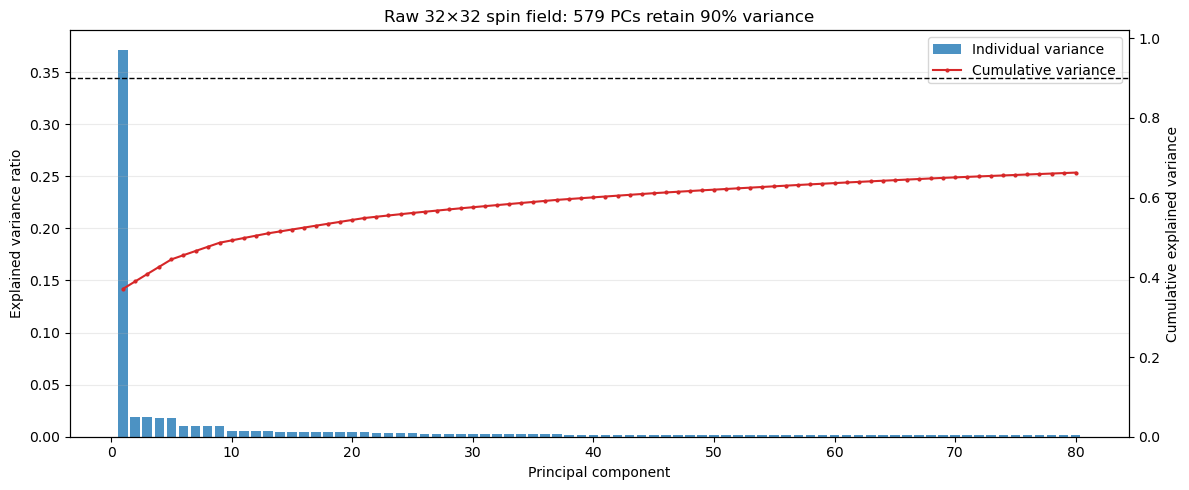

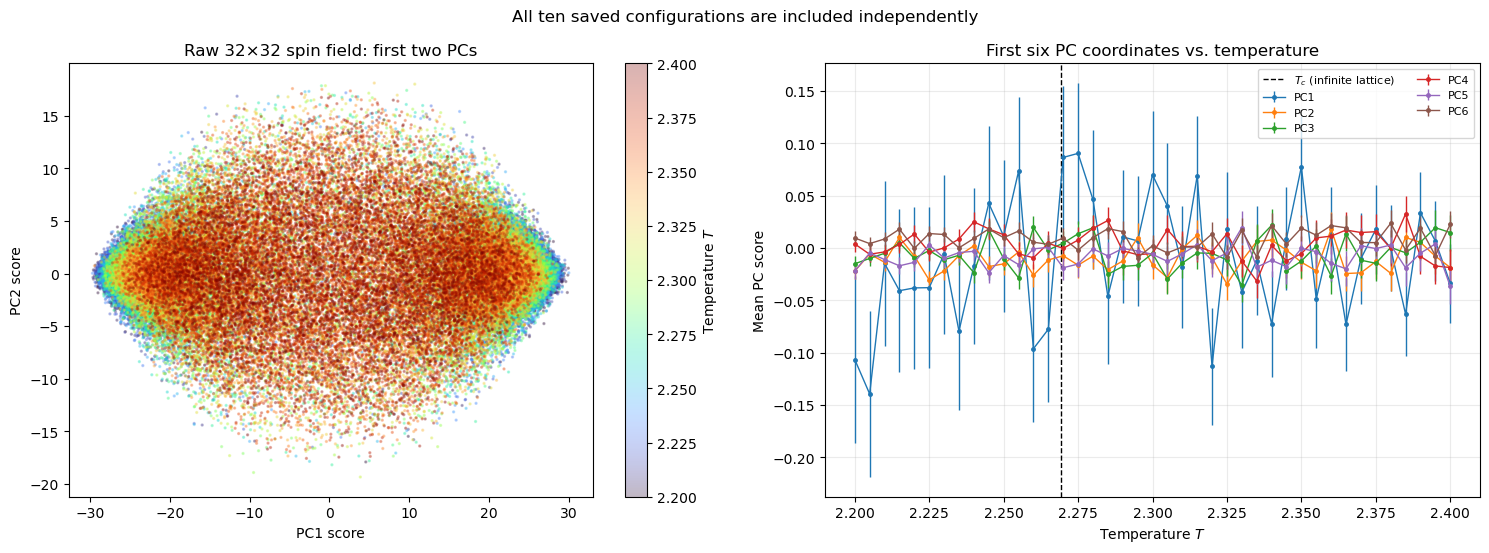

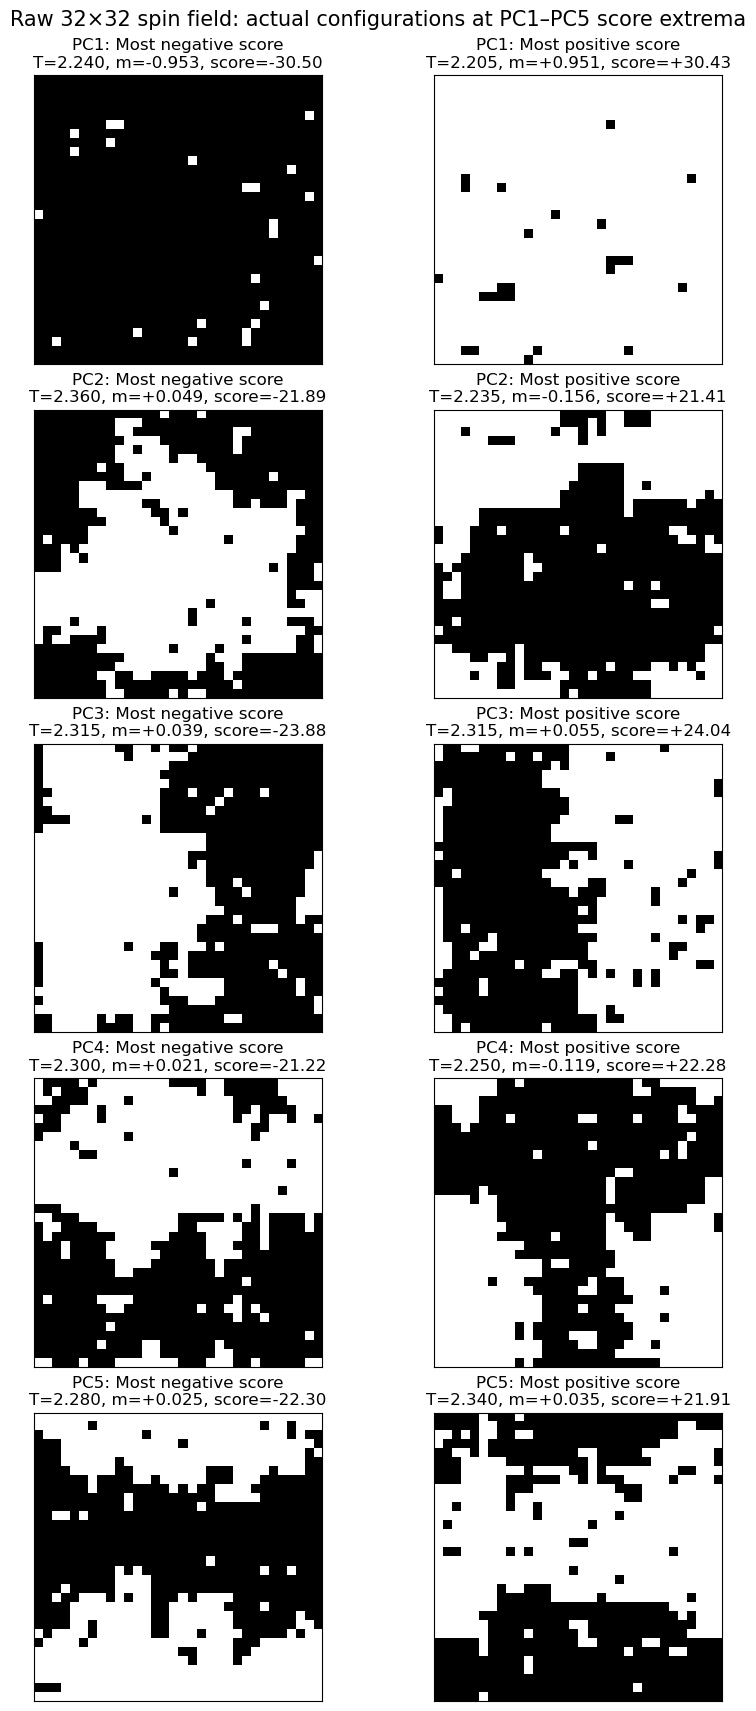

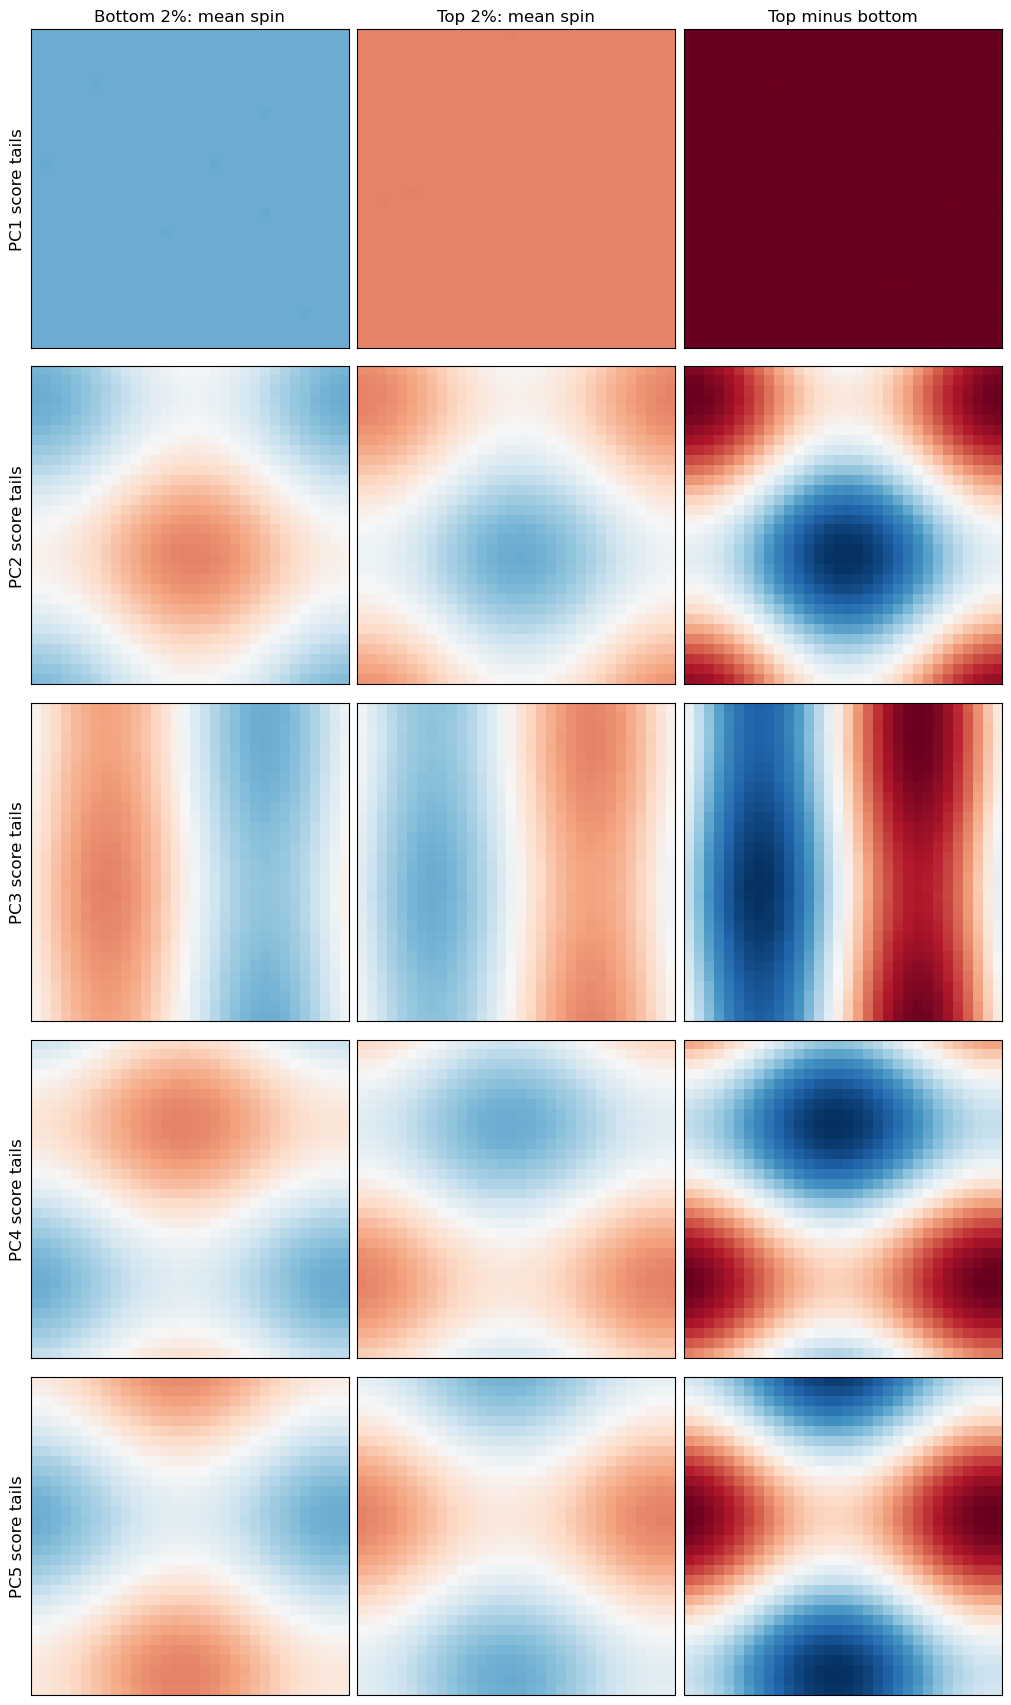

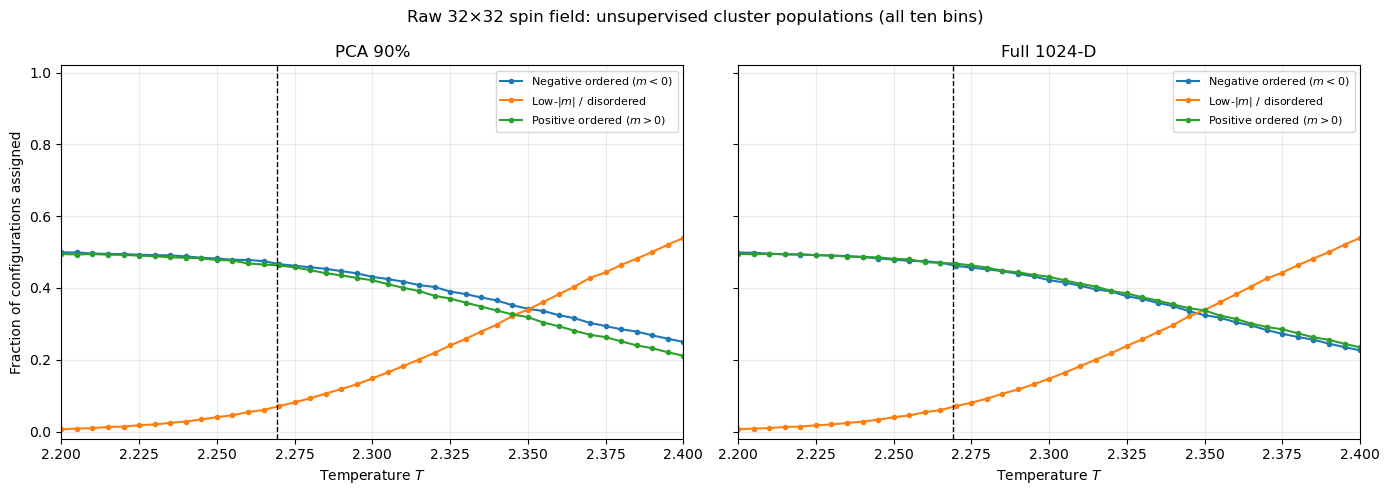

,method,cluster,physical_label,fraction,mean_m,mean_abs_m
0,PCA 90%,0,Negative ordered,0.408997,-0.650719,0.650719
1,PCA 90%,1,Low-|m| / disordered,0.198711,0.027258,0.171621
2,PCA 90%,2,Positive ordered,0.392292,0.664135,0.664135
3,Full 1024-D,0,Negative ordered,0.398618,-0.659340,0.659340
4,Full 1024-D,1,Low-|m| / disordered,0.198255,-0.007755,0.170404
5,Full 1024-D,2,Positive ordered,0.403127,0.655306,0.655306


,method,silhouette,sample_size,PCA_vs_full_AMI
0,PCA 90%,0.209958,5125,0.914107
1,Full 1024-D,0.189365,5125,0.914107


In [4]:
raw_features = all_spins.reshape(N_CONFIGURATIONS, N_SITES)
mean, eigenvalues, components = fit_covariance_pca(raw_features, OUTPUT_ROOT / "raw_spin_all_bins_pca.npz")
evr, cumulative, n90 = variance_plot(eigenvalues, "Raw 32×32 spin field", "raw_spin_all_bins_explained_variance.png")
scores6 = score_first_six(raw_features, mean, components, OUTPUT_ROOT / "raw_spin_all_bins_pc1-6_scores.npy")
overview_plot(scores6, "Raw 32×32 spin field", "raw_spin_all_bins_pca_overview.png")
tail_plots(scores6, "raw_spin_all_bins", "Raw 32×32 spin field")
labels, cluster_summary, diagnostics = streamed_kmeans(raw_features, mean, components, n90, "raw_spin_all_bins", "Raw 32×32 spin field")
with open(OUTPUT_ROOT / "raw_spin_all_bins_summary.json", "w") as handle:
    json.dump({"observations": N_CONFIGURATIONS, "fit_observations": len(FIT_INDICES), "n90": n90, "first_six_evr": evr[:6].tolist()}, handle, indent=2)
display(cluster_summary, diagnostics)

## Direct apples-to-apples comparison

In [5]:
resnet_summary = json.loads((OUTPUT_ROOT / "resnet18_all_bins_summary.json").read_text())
resnet_diag = pd.read_csv(OUTPUT_ROOT / "resnet18_all_bins_cluster_diagnostics.csv")
raw_diag = pd.read_csv(OUTPUT_ROOT / "raw_spin_all_bins_cluster_diagnostics.csv")
comparison = pd.DataFrame({
    "representation": ["Frozen ResNet-18", "Raw spins"],
    "PCs for 90% variance": [resnet_summary["n90"], n90],
    "PCA90 silhouette": [resnet_diag.loc[resnet_diag.method == "PCA 90%", "silhouette"].iloc[0], raw_diag.loc[raw_diag.method == "PCA 90%", "silhouette"].iloc[0]],
    "Full-space silhouette": [resnet_diag.loc[resnet_diag.method.str.startswith("Full"), "silhouette"].iloc[0], raw_diag.loc[raw_diag.method.str.startswith("Full"), "silhouette"].iloc[0]],
})
resnet_pca_labels = np.load(OUTPUT_ROOT / "resnet18_all_bins_pca_cluster_labels.npy", mmap_mode="r")
raw_pca_labels = np.load(OUTPUT_ROOT / "raw_spin_all_bins_pca_cluster_labels.npy", mmap_mode="r")
comparison["Cross-representation PCA90 AMI"] = adjusted_mutual_info_score(resnet_pca_labels, raw_pca_labels)
comparison.to_csv(OUTPUT_ROOT / "matched_resnet_vs_raw_comparison.csv", index=False)
comparison

,representation,PCs for 90% variance,PCA90 silhouette,Full-space silhouette,Cross-representation PCA90 AMI
0,Frozen ResNet-18,32,0.283992,0.240134,0.649003
1,Raw spins,579,0.209958,0.189365,0.649003


## Interpretation

Raw-spin PCA uses the exact same 4.1 million configurations and the exact same balanced 410,000-observation fitting subset as ResNet. It needs **579 PCs** for 90% variance, compared with 32 for ResNet. Its PCA-90 and full-space silhouette scores are **0.210** and **0.189**. The PCA-90 and full raw-spin clusterings agree strongly (AMI **0.914**), while matched ResNet and raw PCA-90 assignments have AMI **0.649**.

Raw PC1 is signed magnetization: its two score tails are nearly uniform negative and positive spin fields. Consequently its signed mean at each temperature is close to zero because the simulation samples both symmetry-related sectors. That cancellation in the *plotted mean score* is physical and is not the earlier preprocessing error; no configurations are averaged before PCA here.

Raw PCs 2–5 display smooth, location-dependent long-wavelength modes. The low-|m| cluster grows from below 1% at T=2.200 to about **54% at T=2.400**. ResNet reaches about 72% over the same observations, showing stronger separation of the high-temperature, low-|m| configurations in this narrow window. ResNet therefore adds useful nonlinear phase separation, while raw PCA remains more directly interpretable through magnetization and spatial Fourier-like modes.